In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("CAT Operator Copilot - Dataset Audit")
print("ML environment ready")

CAT Operator Copilot - Dataset Audit
ML environment ready


In [2]:
machine_df = pd.read_csv("../../data/synthetic_machine_data.csv")
task_df = pd.read_csv("../../data/synthetic_task_data.csv")

print("Machine dataset shape:", machine_df.shape)
print("Task dataset shape:", task_df.shape)

Machine dataset shape: (800, 10)
Task dataset shape: (500, 7)


In [3]:
print("MACHINE DATASET")
print(machine_df.columns.tolist())

print("\nTASK DATASET")
print(task_df.columns.tolist())
machine_df.head()
task_df.head()
print("Machine missing values:")
print(machine_df.isnull().sum())

print("\nTask missing values:")
print(task_df.isnull().sum())
print("Machine data types:")
print(machine_df.dtypes)

print("\nTask data types:")
print(task_df.dtypes)
machine_df.describe()
task_df.describe()

MACHINE DATASET
['Timestamp', 'Machine ID', 'Operator ID', 'Weather', 'Engine Hours', 'Fuel Used (L)', 'Load Cycles', 'Idling Time (min)', 'Seatbelt Status', 'Safety Alert Triggered']

TASK DATASET
['Task ID', 'Task Type', 'Weather', 'Operator Skill', 'Machine Age (yrs)', 'Estimated Time (min)', 'Actual Time (min)']
Machine missing values:
Timestamp                 0
Machine ID                0
Operator ID               0
Weather                   0
Engine Hours              0
Fuel Used (L)             0
Load Cycles               0
Idling Time (min)         0
Seatbelt Status           0
Safety Alert Triggered    0
dtype: int64

Task missing values:
Task ID                 0
Task Type               0
Weather                 0
Operator Skill          0
Machine Age (yrs)       0
Estimated Time (min)    0
Actual Time (min)       0
dtype: int64
Machine data types:
Timestamp                     str
Machine ID                    str
Operator ID                   str
Weather                   

,Machine Age (yrs),Estimated Time (min),Actual Time (min)
count,500.000000,500.000000,500.000000
mean,5.566000,54.694000,65.214000
std,2.788044,22.721463,23.339015
min,1.000000,25.000000,13.000000
25%,3.000000,35.000000,46.000000
50%,5.000000,49.000000,61.000000
75%,8.000000,67.000000,82.000000
max,10.000000,98.000000,120.000000


In [4]:
# Task dataset: unique values and distributions

print("TASK TYPES")
print(task_df["Task Type"].value_counts())
print()

print("WEATHER")
print(task_df["Weather"].value_counts())
print()

print("OPERATOR SKILL")
print(task_df["Operator Skill"].value_counts())
print()

print("MACHINE AGE")
print(task_df["Machine Age (yrs)"].value_counts().sort_index())
task_df["Time Difference"] = (
    task_df["Actual Time (min)"] -
    task_df["Estimated Time (min)"]
)

print(task_df["Time Difference"].describe())
print("Average difference:",
      task_df["Time Difference"].mean())

print("Minimum difference:",
      task_df["Time Difference"].min())

print("Maximum difference:",
      task_df["Time Difference"].max())

print(
    task_df.groupby("Weather")[
        ["Estimated Time (min)", "Actual Time (min)", "Time Difference"]
    ].mean()
)

print(
    task_df.groupby("Operator Skill")[
        ["Estimated Time (min)", "Actual Time (min)", "Time Difference"]
    ].mean()
)
print(
    task_df.groupby("Task Type")[
        ["Estimated Time (min)", "Actual Time (min)", "Time Difference"]
    ].mean()
)
print(
    task_df.groupby("Machine Age (yrs)")[
        ["Estimated Time (min)", "Actual Time (min)", "Time Difference"]
    ].mean()
)

TASK TYPES
Task Type
Earth Excavation    111
Demolition          110
Material Loading    108
Grading              86
Trenching            85
Name: count, dtype: int64

WEATHER
Weather
Sunny     150
Windy     134
Cloudy    123
Rainy      93
Name: count, dtype: int64

OPERATOR SKILL
Operator Skill
Intermediate    226
Beginner        176
Expert           98
Name: count, dtype: int64

MACHINE AGE
Machine Age (yrs)
1     40
2     48
3     42
4     66
5     56
6     57
7     48
8     44
9     43
10    56
Name: count, dtype: int64
count    500.000000
mean      10.520000
std        6.770619
min      -18.000000
25%        7.000000
50%       10.000000
75%       14.000000
max       40.000000
Name: Time Difference, dtype: float64
Average difference: 10.52
Minimum difference: -18
Maximum difference: 40
         Estimated Time (min)  Actual Time (min)  Time Difference
Weather                                                          
Cloudy              57.390244          67.333333         9.943089
R

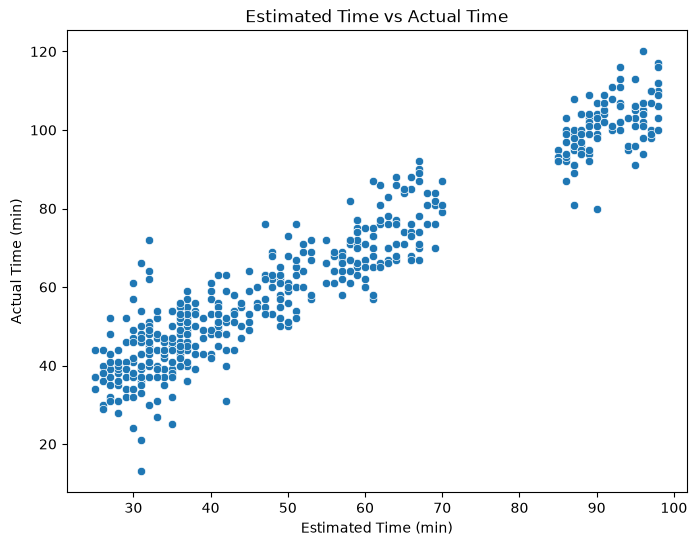

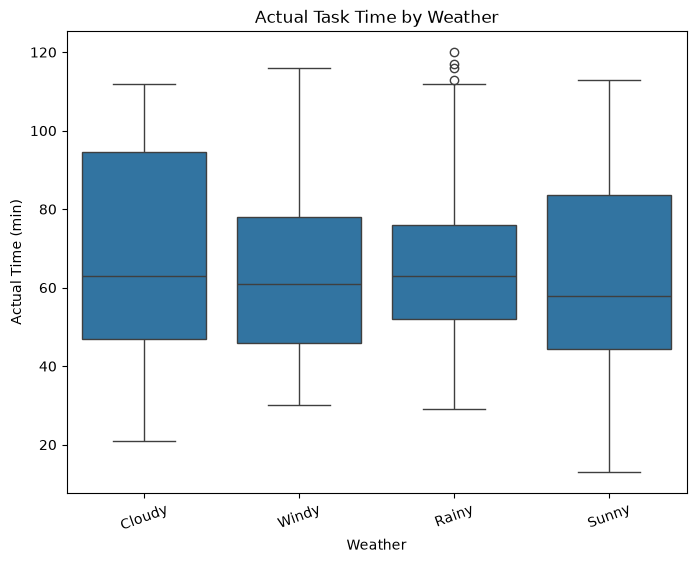

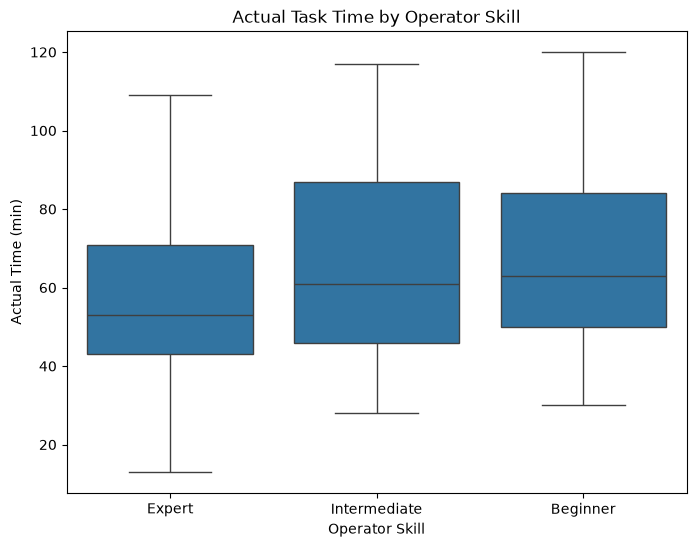

MACHINE DATASET SHAPE: (800, 10)

MACHINES
Machine ID
EXC004    169
EXC003    163
EXC005    158
EXC002    157
EXC001    153
Name: count, dtype: int64

OPERATORS
Operator ID
OP1007    91
OP1004    87
OP1009    85
OP1002    82
OP1008    81
OP1003    79
OP1005    77
OP1006    76
OP1001    71
OP1010    71
Name: count, dtype: int64

WEATHER
Weather
Sunny     238
Cloudy    211
Windy     185
Rainy     166
Name: count, dtype: int64

SEATBELT
Seatbelt Status
Fastened      727
Unfastened     73
Name: count, dtype: int64

SAFETY ALERT
Safety Alert Triggered
No     704
Yes     96
Name: count, dtype: int64


,Fuel Used (L),Load Cycles,Idling Time (min)
Machine ID,,,
EXC001,3.55,7.97,32.79
EXC002,3.16,7.18,33.52
EXC003,3.17,7.06,34.78
EXC004,3.51,7.74,35.25
EXC005,3.27,7.34,33.84


In [5]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=task_df,
    x="Estimated Time (min)",
    y="Actual Time (min)"
)

plt.title("Estimated Time vs Actual Time")
plt.xlabel("Estimated Time (min)")
plt.ylabel("Actual Time (min)")
plt.show()

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=task_df,
    x="Weather",
    y="Actual Time (min)"
)

plt.title("Actual Task Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Actual Time (min)")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=task_df,
    x="Operator Skill",
    y="Actual Time (min)"
)

plt.title("Actual Task Time by Operator Skill")
plt.xlabel("Operator Skill")
plt.ylabel("Actual Time (min)")
plt.show()

print("MACHINE DATASET SHAPE:", machine_df.shape)

print("\nMACHINES")
print(machine_df["Machine ID"].value_counts())

print("\nOPERATORS")
print(machine_df["Operator ID"].value_counts())

print("\nWEATHER")
print(machine_df["Weather"].value_counts())

print("\nSEATBELT")
print(machine_df["Seatbelt Status"].value_counts())

print("\nSAFETY ALERT")
print(machine_df["Safety Alert Triggered"].value_counts())

machine_df.describe()

machine_df.groupby("Operator ID")[
    ["Fuel Used (L)", "Load Cycles", "Idling Time (min)"]
].mean().round(2)

machine_df.groupby("Machine ID")[
    ["Fuel Used (L)", "Load Cycles", "Idling Time (min)"]
].mean().round(2)